In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from pytorch_model_summary import summary

In [2]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        if mode == 'train':
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == 'val':
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

In [3]:
# Chakraborty & Chakravarty, "A new discrete probability distribution with integer support on (−∞, ∞)",
#  Communications in Statistics - Theory and Methods, 45:2, 492-505, DOI: 10.1080/03610926.2013.830743

def log_min_exp(a, b, epsilon=1e-8):
    """
    Source: https://github.com/jornpeters/integer_discrete_flows
    Computes the log of exp(a) - exp(b) in a (more) numerically stable fashion.
    Using:
     log(exp(a) - exp(b))
     c + log(exp(a-c) - exp(b-c))
     a + log(1 - exp(b-a))
    And note that we assume b < a always.
    """
    y = a + torch.log(1 - torch.exp(b - a) + epsilon)

    return y

def log_integer_probability(x, mean, logscale):
    scale = torch.exp(logscale)

    logp = log_min_exp(
        F.logsigmoid((x + 0.5 - mean) / scale),
        F.logsigmoid((x - 0.5 - mean) / scale))

    return logp

In [4]:
# Source: https://github.com/jornpeters/integer_discrete_flows
class RoundStraightThrough(torch.autograd.Function):
    
    def __init__(self):
        super().__init__()

    @staticmethod
    def forward(ctx, input):
        rounded = torch.round(input, out=None)
        return rounded

    @staticmethod
    def backward(ctx, grad_output):
        grad_input = grad_output.clone()
        return grad_input

In [5]:
class IDF(nn.Module):
    def __init__(self, netts, num_flows, D=2):
        super(IDF, self).__init__()

        print('IDF by JT.')
        
        if len(netts) == 1:
            self.t = torch.nn.ModuleList([netts[0]() for _ in range(num_flows)])
            self.idf_git = 1
        
        elif len(netts) == 4:
            self.t_a = torch.nn.ModuleList([netts[0]() for _ in range(num_flows)])
            self.t_b = torch.nn.ModuleList([netts[1]() for _ in range(num_flows)])
            self.t_c = torch.nn.ModuleList([netts[2]() for _ in range(num_flows)])
            self.t_d = torch.nn.ModuleList([netts[3]() for _ in range(num_flows)])
            self.idf_git = 4
        
        else:
            raise ValueError('You can provide either 1 or 4 translation nets.')
        
        self.num_flows = num_flows

        self.round = RoundStraightThrough.apply
        
        self.mean = nn.Parameter(torch.zeros(1, D))
        self.logscale = nn.Parameter(torch.ones(1, D))

        self.D = D

    def coupling(self, x, index, forward=True):
        
        if self.idf_git == 1:
            (xa, xb) = torch.chunk(x, 2, 1)
            
            if forward:
                yb = xb + self.round(self.t[index](xa))
            else:
                yb = xb - self.round(self.t[index](xa))
            
            return torch.cat((xa, yb), 1)
        
        elif self.idf_git == 4:
            (xa, xb, xc, xd) = torch.chunk(x, 4, 1)
            
            if forward:
                ya = xa + self.round(self.t_a[index](torch.cat((xb, xc, xd), 1)))
                yb = xb + self.round(self.t_b[index](torch.cat((ya, xc, xd), 1)))
                yc = xc + self.round(self.t_c[index](torch.cat((ya, yb, xd), 1)))
                yd = xd + self.round(self.t_d[index](torch.cat((ya, yb, yc), 1)))
            else:
                yd = xd - self.round(self.t_d[index](torch.cat((xa, xb, xc), 1)))
                yc = xc - self.round(self.t_c[index](torch.cat((xa, xb, yd), 1)))
                yb = xb - self.round(self.t_b[index](torch.cat((xa, yc, yd), 1)))
                ya = xa - self.round(self.t_a[index](torch.cat((yb, yc, yd), 1)))
            
            return torch.cat((ya, yb, yc, yd), 1)

    def permute(self, x):
        return x.flip(1)

    def f(self, x):
        z = x
        for i in range(self.num_flows):
            z = self.coupling(z, i, forward=True)
            z = self.permute(z)

        return z

    def f_inv(self, z):
        x = z
        for i in reversed(range(self.num_flows)):
            x = self.permute(x)
            x = self.coupling(x, i, forward=False)

        return x

    def forward(self, x, reduction='avg'):
        z = self.f(x)
        if reduction == 'sum':
            return -self.log_prior(z).sum()
        else:
            return -self.log_prior(z).mean()

    def sample(self, batchSize):
        # sample z:
        z = self.prior_sample(batchSize=batchSize, D=self.D)
        # x = f^-1(z)
        x = self.f_inv(z)
        return x.view(batchSize, 1, self.D)

    def log_prior(self, x):
        log_p = log_integer_probability(x, self.mean, self.logscale)
        return log_p.sum(1)

    def prior_sample(self, batchSize, D=2):
        # Sample from logistic
        y = torch.rand(batchSize, self.D)
        x = torch.exp(self.logscale) * torch.log(y / (1. - y)) + self.mean
        # And then round it to an integer.
        return torch.round(x)

In [6]:
def evaluation(test_loader, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        raise ValueError('Please provide model_best when evaluating; no model is loaded from disk.')

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, axes = plt.subplots(num_x, num_y)
    for i, ax in enumerate(axes.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def samples_generated(model, data_loader, extra_name=''):
    x = next(iter(data_loader)).detach().numpy()

    # GENERATIONS-------
    model.eval()

    num_x = 4
    num_y = 4
    x = model.sample(num_x * num_y)
    x = x.detach().numpy()

    fig, axes = plt.subplots(num_x, num_y)
    for i, ax in enumerate(axes.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def plot_curve(nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('nll')
    plt.tight_layout()
    plt.show()

In [7]:
def training(max_patience, num_epochs, model, optimizer, training_loader, val_loader):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)

        if loss_val < best_nll:
            best_nll = loss_val
            patience = 0
        else:
            patience = patience + 1

        if e % 5 == 0:
            samples_generated(model, val_loader, extra_name="_epoch_" + str(e))

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)
    return nll_val

In [8]:
train_data = Digits(mode='train')
val_data = Digits(mode='val')
test_data = Digits(mode='test')

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [9]:
D = 64   # input dimension
M = 256  # the number of neurons in scale (s) and translation (t) nets

lr = 1e-3 # learning rate
num_epochs = 1000 # max. number of epochs
max_patience = 20 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

In [10]:
# The number of invertible transformations
num_flows = 8

# This variable defines whether we use: 
#   1 - the classic coupling layer proposed in (Hogeboom et al., 2019)
#   4 - the general invertible transformation in (Tomczak, 2020) with 4 partitions
idf_git = 4

if idf_git == 1:
    nett = lambda: nn.Sequential(nn.Linear(D // 2, M), nn.LeakyReLU(),
                                     nn.Linear(M, M), nn.LeakyReLU(),
                                     nn.Linear(M, D // 2))
    netts = [nett]

elif idf_git == 4:
    nett_a = lambda: nn.Sequential(nn.Linear(3 * (D // 4), M), nn.LeakyReLU(),
                                       nn.Linear(M, M), nn.LeakyReLU(),
                                       nn.Linear(M, D // 4))

    nett_b = lambda: nn.Sequential(nn.Linear(3 * (D // 4), M), nn.LeakyReLU(),
                                       nn.Linear(M, M), nn.LeakyReLU(),
                                       nn.Linear(M, D // 4))

    nett_c = lambda: nn.Sequential(nn.Linear(3 * (D // 4), M), nn.LeakyReLU(),
                                       nn.Linear(M, M), nn.LeakyReLU(),
                                       nn.Linear(M, D // 4))

    nett_d = lambda: nn.Sequential(nn.Linear(3 * (D // 4), M), nn.LeakyReLU(),
                                       nn.Linear(M, M), nn.LeakyReLU(),
                                       nn.Linear(M, D // 4))
    
    netts = [nett_a, nett_b, nett_c, nett_d]

# Init IDF
model = IDF(netts, num_flows, D=D)
# Print the summary (like in Keras)
print(summary(model, torch.zeros(1, 64), show_input=False, show_hierarchical=False))

IDF by JT.
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]          12,544          12,544
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]          65,792          65,792
       LeakyReLU-4            [1, 256]               0               0
          Linear-5             [1, 16]           4,112           4,112
          Linear-6            [1, 256]          12,544          12,544
       LeakyReLU-7            [1, 256]               0               0
          Linear-8            [1, 256]          65,792          65,792
       LeakyReLU-9            [1, 256]               0               0
         Linear-10             [1, 16]           4,112           4,112
         Linear-11            [1, 256]          12,544          12,544
      LeakyReLU-12            [1, 256]               0           

In [11]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

Epoch: 0, val nll=178.57373046875


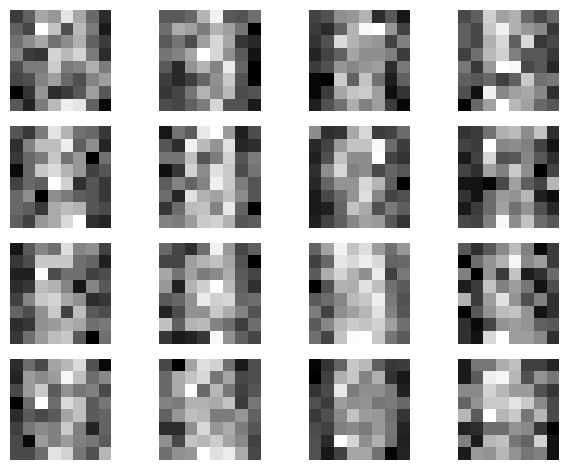

Epoch: 1, val nll=174.74205915178572
Epoch: 2, val nll=172.63431919642858
Epoch: 3, val nll=170.7708189174107
Epoch: 4, val nll=169.00109793526786
Epoch: 5, val nll=167.76177734375


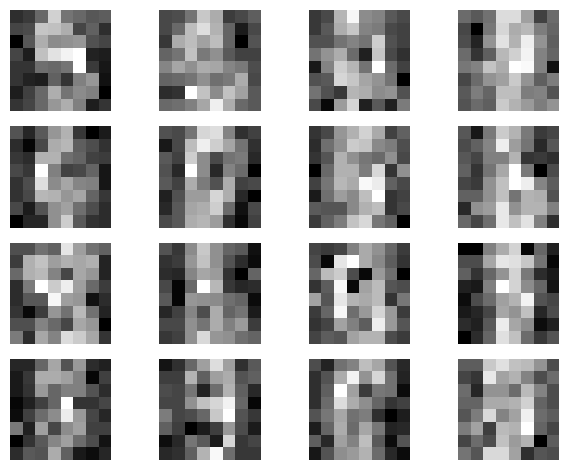

Epoch: 6, val nll=166.47144252232144
Epoch: 7, val nll=165.57530970982143
Epoch: 8, val nll=164.36625279017858
Epoch: 9, val nll=163.63594447544642
Epoch: 10, val nll=162.86112723214285


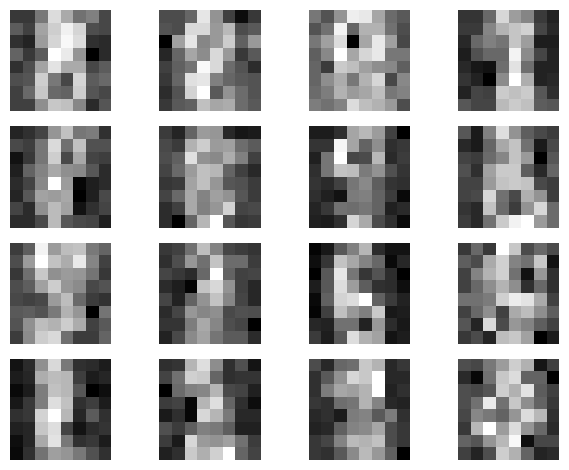

Epoch: 11, val nll=161.81830357142857
Epoch: 12, val nll=161.43798828125
Epoch: 13, val nll=160.37812220982144
Epoch: 14, val nll=160.01371372767858
Epoch: 15, val nll=159.250654296875


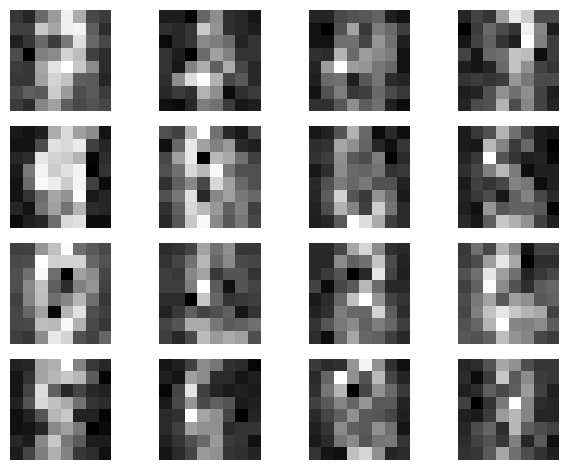

Epoch: 16, val nll=158.594482421875
Epoch: 17, val nll=157.96581473214286
Epoch: 18, val nll=157.38766322544643
Epoch: 19, val nll=157.0625083705357
Epoch: 20, val nll=156.38375279017856


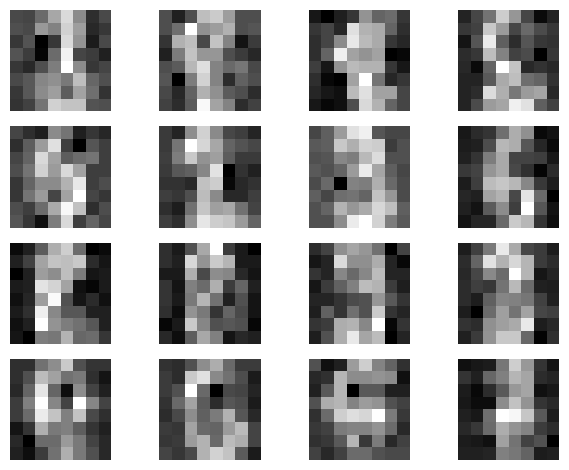

Epoch: 21, val nll=155.93300641741072
Epoch: 22, val nll=155.46465262276786
Epoch: 23, val nll=155.0323228236607
Epoch: 24, val nll=154.34566127232142
Epoch: 25, val nll=153.94194056919642


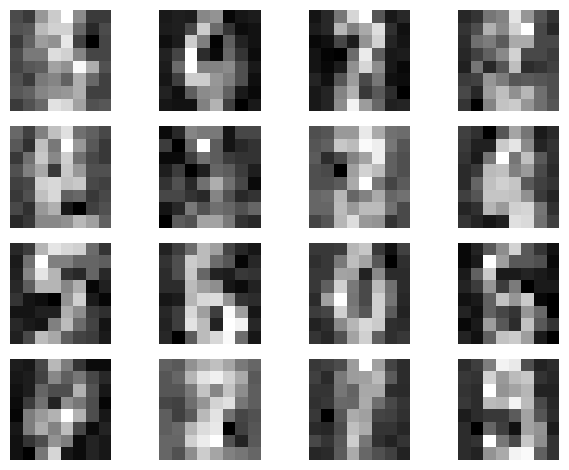

Epoch: 26, val nll=153.64128208705358
Epoch: 27, val nll=153.37750279017857
Epoch: 28, val nll=152.87451450892857
Epoch: 29, val nll=152.33418247767858
Epoch: 30, val nll=151.92305385044642


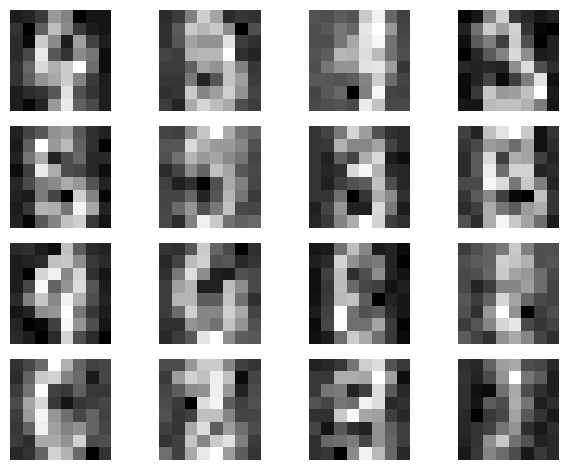

Epoch: 31, val nll=151.66915457589286
Epoch: 32, val nll=151.37773158482142
Epoch: 33, val nll=151.15244977678572
Epoch: 34, val nll=150.66074637276785
Epoch: 35, val nll=150.51159458705357


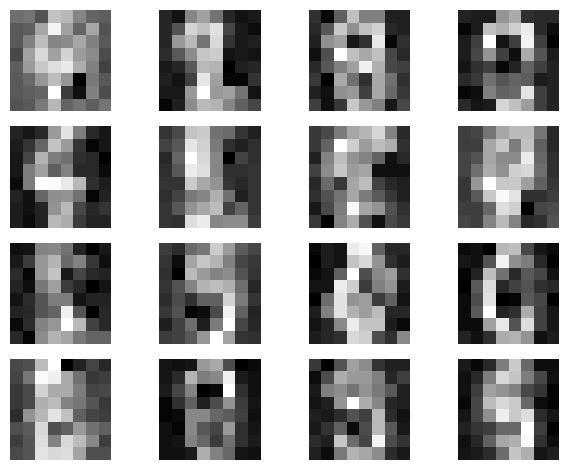

Epoch: 36, val nll=150.46106724330357
Epoch: 37, val nll=149.779853515625
Epoch: 38, val nll=149.43840680803572
Epoch: 39, val nll=149.14044363839287
Epoch: 40, val nll=148.60187639508928


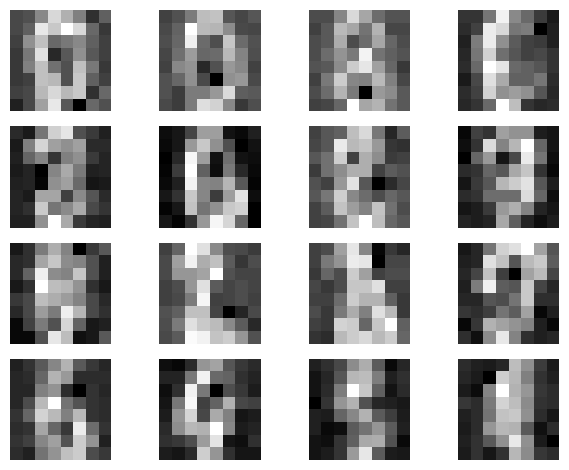

Epoch: 41, val nll=148.5618638392857
Epoch: 42, val nll=147.91973911830357
Epoch: 43, val nll=148.00555803571427
Epoch: 44, val nll=147.54391183035713
Epoch: 45, val nll=147.34675223214285


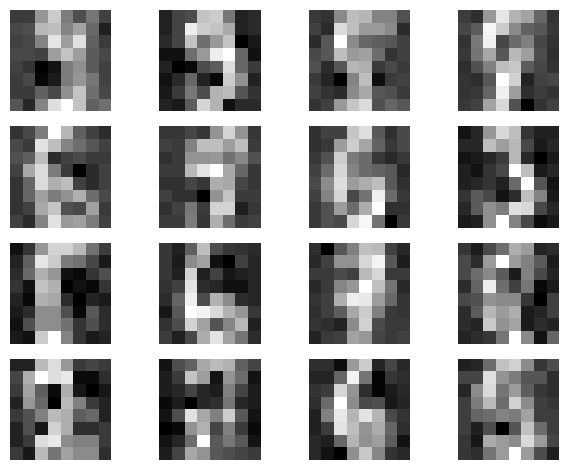

Epoch: 46, val nll=146.81148856026786
Epoch: 47, val nll=146.41435128348215
Epoch: 48, val nll=146.2864662388393
Epoch: 49, val nll=146.4602553013393
Epoch: 50, val nll=146.1653515625


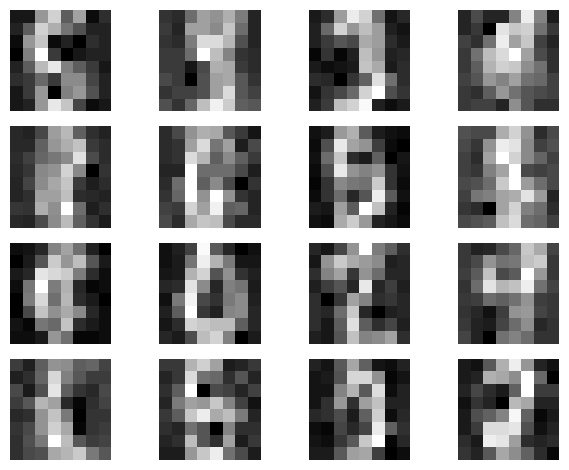

Epoch: 51, val nll=145.54935546875
Epoch: 52, val nll=146.08598353794642
Epoch: 53, val nll=145.74528459821428
Epoch: 54, val nll=145.2573046875
Epoch: 55, val nll=145.74097237723214


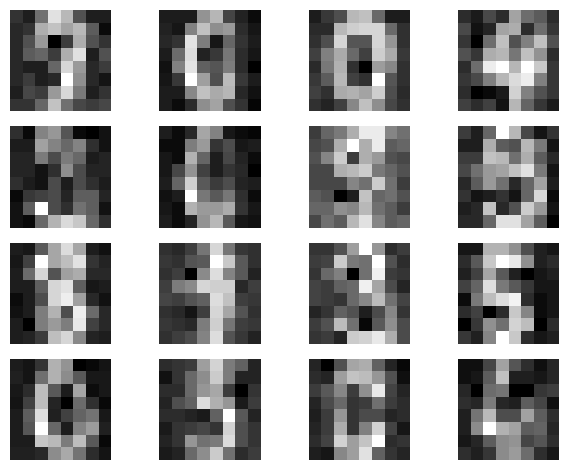

Epoch: 56, val nll=145.03019949776785
Epoch: 57, val nll=145.55511997767857
Epoch: 58, val nll=145.28729771205357
Epoch: 59, val nll=145.02896484375
Epoch: 60, val nll=144.95156808035713


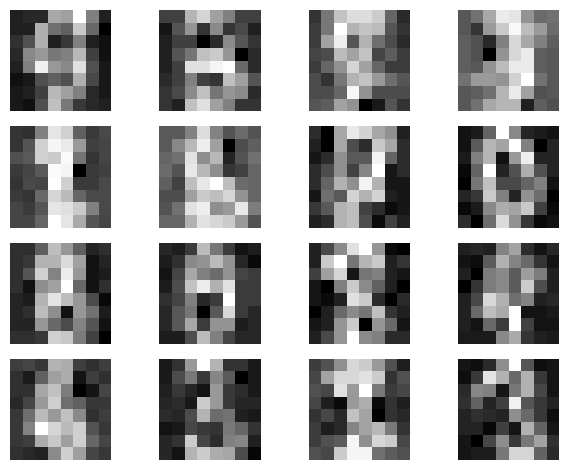

Epoch: 61, val nll=144.638173828125
Epoch: 62, val nll=145.14962472098213
Epoch: 63, val nll=144.331455078125
Epoch: 64, val nll=144.04954520089285
Epoch: 65, val nll=144.38902204241072


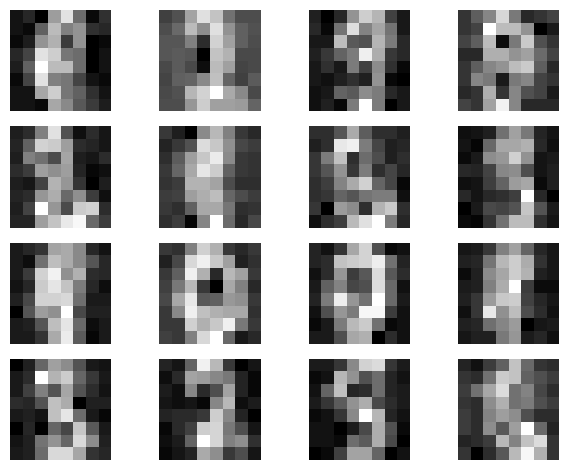

Epoch: 66, val nll=144.64592633928572
Epoch: 67, val nll=144.57345982142857
Epoch: 68, val nll=144.15448939732144
Epoch: 69, val nll=144.35918387276786
Epoch: 70, val nll=144.7046205357143


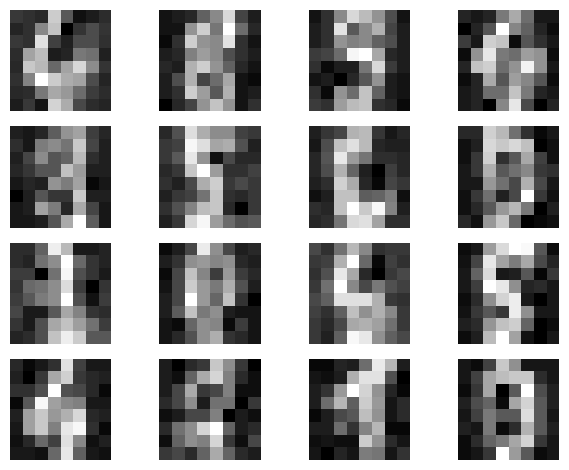

Epoch: 71, val nll=144.51764229910714
Epoch: 72, val nll=144.4584584263393
Epoch: 73, val nll=144.39167829241072
Epoch: 74, val nll=145.06436802455357
Epoch: 75, val nll=145.22133370535715


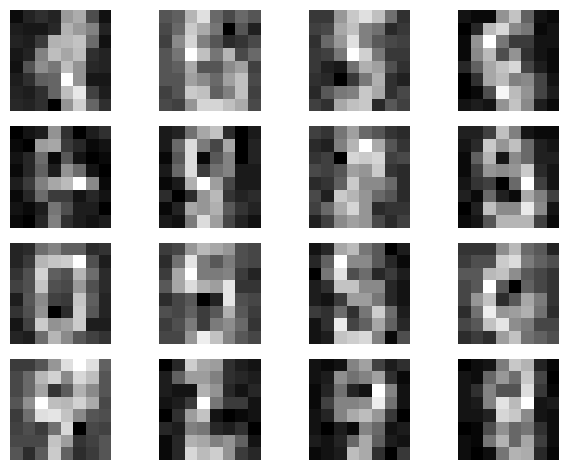

Epoch: 76, val nll=144.73770647321427
Epoch: 77, val nll=146.07189453125
Epoch: 78, val nll=145.14711216517858
Epoch: 79, val nll=145.08115931919642
Epoch: 80, val nll=145.26071986607144


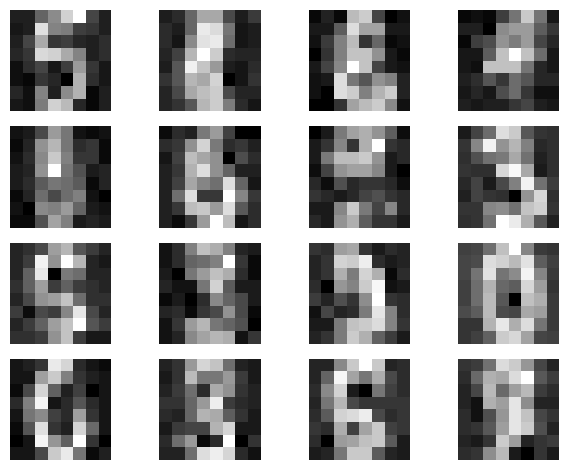

Epoch: 81, val nll=145.64362862723215
Epoch: 82, val nll=145.55824776785715
Epoch: 83, val nll=145.67737025669643
Epoch: 84, val nll=146.0403515625
Epoch: 85, val nll=146.45309849330357


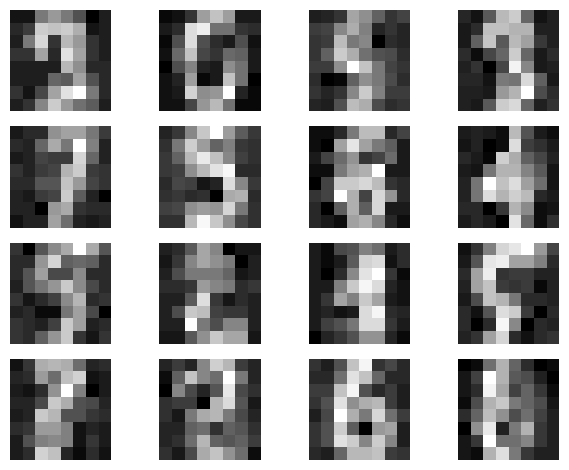

In [12]:
# Training procedure
nll_val = training(max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                  training_loader=training_loader, val_loader=val_loader)

FINAL LOSS: nll=144.0334587353188
Final test loss: 144.0334587353188


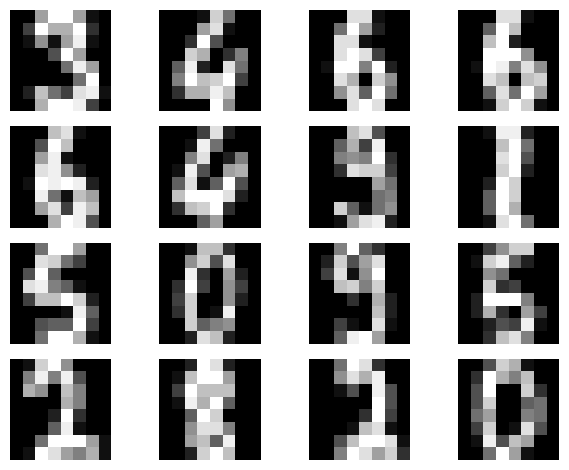

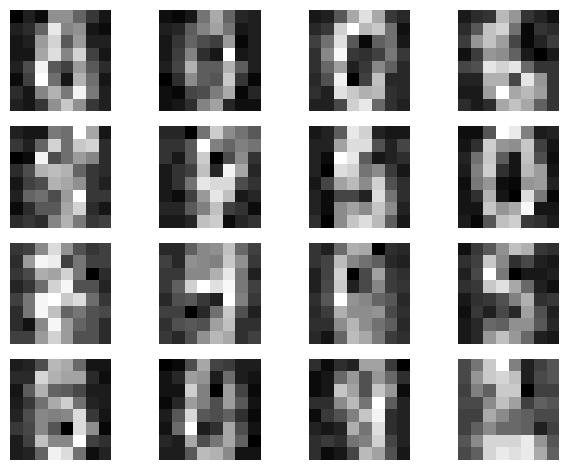

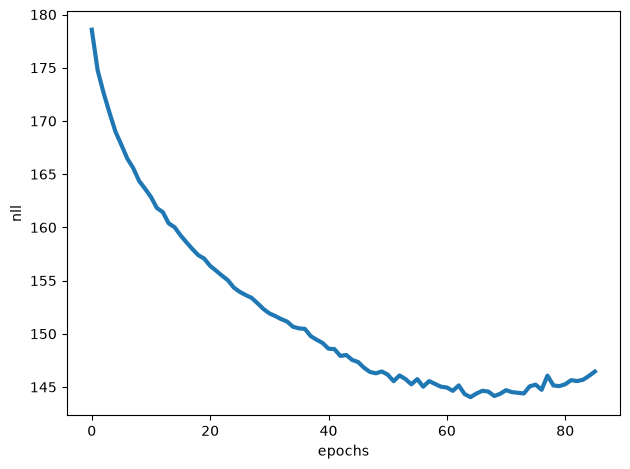

In [13]:
test_loss = evaluation(test_loader=test_loader, model_best=model)
print(f'Final test loss: {test_loss}')

samples_real(test_loader)
samples_generated(model, val_loader)
plot_curve(nll_val)